## Basic Chunking

In [ ]:
from typing import  TypedDict, List
from pydantic import  BaseModel
from langchain_groq import  ChatGroq
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_text_splitters import  RecursiveCharacterTextSplitter
from langchain_community.document_loaders import Docx2txtLoader
from langchain_core.documents import Document
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
chat_model = ChatGroq(model="openai/gpt-oss-120b")
eval_model = ChatGroq(model="llama-3.3-70b-versatile")
embedding_model = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

In [3]:
loader = Docx2txtLoader("../data/Final CHATBOT data requirements.docx")
docs = loader.load()

In [4]:
splitter = RecursiveCharacterTextSplitter(
    separators=[
        r"\n\d+\.\s",
        "\n\n",
        "\n",
        " ",
        ""
    ],
    is_separator_regex=True,
    chunk_size=1000,        # good for embeddings / RAG
    chunk_overlap=150,
    keep_separator="start",
    strip_whitespace=True
)
chunks = splitter.split_documents(docs)
print(f"Number of chunks: {len(chunks)}")

Number of chunks: 37


In [6]:
chunks[35].page_content

'7. Are there prerequisites for any courses?\n\nMost beginner-level courses have no prerequisites and are designed for students with no prior experience. Advanced courses may require knowledge of basic concepts from earlier levels or related courses. For example:\n\nUnity & Game Development (Advanced): Requires familiarity with coding basics.\n\nPython Programming (Intermediate/Advanced): Builds on beginner-level concepts.\n\n\n\n8. Can students enroll in multiple courses at the same time?\n\nYes! Students can enroll in multiple courses simultaneously if they can manage the workload. For example, a student interested in both Python programming and UI/UX design can pursue them together.\n\n\n\n9. What if my child is unsure which course to take?\n\nOur team is happy to provide personalized course recommendations based on your child’s age, interests, and skill level. Contact us for a consultation!\n\n\n\n10. Are there trial classes available to explore courses?'

In [7]:
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [10]:
embed = embedding_model.embed_query("Hello")

In [11]:
len(embed)

3072

## FAISS Connections

In [8]:
from langchain_community.vectorstores import  FAISS

vector_store = FAISS.from_documents(
    chunks, embedding_model
)
index_name = "my_faiss_index"
vector_store.save_local(index_name)

In [ ]:
new_vector_store = FAISS.load_local(
    folder_path = "steaminds-vector-store",
    index_name="index",
    allow_dangerous_deserialization=True,
    embedding_model,
)

## Similarity Search

In [10]:
query = "Are there trial classes available to explore courses?"
result = new_vector_store.similarity_search(query, k=3)

In [14]:
for i in result:
    print(i.page_content, "")

10. Are there trial classes available to explore courses?

Yes, we offer trial sessions for all courses so students can experience the learning style and content before committing to a full program. 
7. Are there prerequisites for any courses?

Most beginner-level courses have no prerequisites and are designed for students with no prior experience. Advanced courses may require knowledge of basic concepts from earlier levels or related courses. For example:

Unity & Game Development (Advanced): Requires familiarity with coding basics.

Python Programming (Intermediate/Advanced): Builds on beginner-level concepts.



8. Can students enroll in multiple courses at the same time?

Yes! Students can enroll in multiple courses simultaneously if they can manage the workload. For example, a student interested in both Python programming and UI/UX design can pursue them together.



9. What if my child is unsure which course to take?

Our team is happy to provide personalized course recommendatio

## Corrective RAG

In [24]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [25]:
from typing import TypedDict, List, Annotated
from langchain_core.documents import Document
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

class State(TypedDict):
    query: str
    documents: List[Document]
    response: str
    refined_context: str
    good_docs: List[Document]
    messages: Annotated[List[BaseMessage], add_messages]

In [26]:
def reterivalNode(state: State) -> State:
    q = state["query"]
    docs = vector_store.similarity_search(q, k=3)
    return {"documents": docs}


In [27]:
from langchain_core.prompts import ChatPromptTemplate
# Score-Based Doc Eval
class DocEvalScore(BaseModel):
    score: float

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | eval_model.with_structured_output(DocEvalScore)

In [28]:
def eval_retrieval(state: State) -> State:
    question = state["query"]
    
    score : List[float] = []
    good : List[Document] =[]

    for doc in state["documents"]:
        doc_eval_chain_out = doc_eval_chain.invoke({
            "question" : question,
            "chunk" : doc.page_content
        })
        # print("=========EVAL RETERIVAL=========")
        # print(doc_eval_chain_out)
        # print("=========EVAL RETERIVAL=========\n\n")
        score.append(doc_eval_chain_out.score)

        if doc_eval_chain_out.score > LOWER_TH:
            good.append(doc)
    
    
    refined_context = "\n".join([doc.page_content for doc in good])
    # print("refined_context::: ", refined_context)
    return {
        "good_docs" : good,
        "refined_context" : refined_context
    }

In [29]:
# SYSTEM_PROMPT = """You are SteamMinds Chatbot, a professional AI assistant designed to help users by providing accurate information strictly related to SteamMinds.

# ##  Scope of Knowledge
# - You must answer only using the information available in the provided context.
# - The provided context is your sole source of truth.
# - Do not use external knowledge.
# - Do not guess or fabricate information.

# ## When Responding to Queries
# - If the query is relevant to SteamMinds and supported by the context:
# - Provide a clear, accurate, and concise answer.
# - Maintain a polite and professional tone.
# - Present information in a structured and easy-to-understand way.

# ### If the query is NOT related to SteamMinds:
# - Respond politely:
# "I am the SteamMinds chatbot, and I am designed to assist with questions related to SteamMinds. I currently only have knowledge about SteamMinds and its services. Please feel free to ask anything related to SteamMinds."

# ### If the query is related to SteamMinds BUT the answer is not present in the context:
# - Respond politely:
# "I’m sorry, but I couldn’t find that information in my current SteamMinds knowledge. Please contact SteamMinds support for further assistance."

# ## Communication Style
# - Always be polite, professional, and helpful
# - Be clear and concise
# - Avoid unnecessary details
#     - Do not mention:
#     - retrieved context
#     - documents
#     - knowledge base
#     - internal reasoning

# ## Critical Rules
# - Do NOT hallucinate
# - Do NOT assume
# - Do NOT generate unsupported facts
# - Use only verified context information

# ## Primary Objective
# - Your purpose is to:
#     - Provide accurate SteamMinds information
#     - Ensure reliability and trustworthiness
#     - Maintain professionalism
#     - Prevent misinformation
# """

SYSTEM_PROMPT = "You are SteamMinds Chatbot."

In [30]:
from langchain_core.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", SYSTEM_PROMPT),
        MessagesPlaceholder(variable_name="chat_history"),
        ("human", "Question: {question}\n\n Context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    history = state.get("messages", [])
    response = (answer_prompt | chat_model).invoke(
        {
            "question": state["query"],
            "refined_context": state["refined_context"],
            "chat_history" : history
        }
    )
    # print("========ANSWER=========")
    # print(response.content)
    # print("========ANSWER=========")
    return {
        "response": response.content,
        "messages": [
            HumanMessage(content=state["query"]),
            AIMessage(content=response.content)
        ]
    }

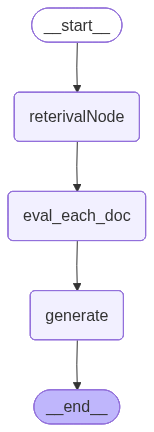

In [31]:
from langgraph.graph import StateGraph, END, START
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
g = StateGraph(State)
g.add_node("reterivalNode", reterivalNode)
g.add_node("eval_each_doc", eval_retrieval)
g.add_node("generate", generate)


g.add_edge(START, "reterivalNode")
g.add_edge("reterivalNode", "eval_each_doc")
g.add_edge("eval_each_doc", "generate")
g.add_edge("generate", END)

app = g.compile(checkpointer=memory)
app

In [36]:
# from langchain_core.messages import HumanMessage
userinput = "What is Steam Minds"
config = {"configurable": {"thread_id": "1"}}
res = app.invoke(
    {
        "query": userinput,
        "messages": [],
        "documents": [],
        "good_docs": [],
        "refined_context": "",
        "response": "",
    },
    config = config
)

In [37]:
res['response']

'**Steam Minds** (styled as **STEAM\u202fMinds**) is an education technology company that delivers skill‑based, STEAM‑focused learning experiences for K‑12 students worldwide.  \n\nIts core offering combines:\n\n- **AI‑driven personalized learning** that adapts to each learner’s pace and needs.  \n- **Immersive VR/AR environments** for hands‑on, gamified exploration of science, technology, engineering, arts, and mathematics.  \n- **Project‑based activities** such as coding, problem‑solving, and scientific experiments that develop real‑world, tech‑savvy skills.  \n\nThe company is officially incorporated in Pakistan (registered with the Securities and Exchange Commission of Pakistan, the Pakistan Software Export Board, and has a physical office in Abbottabad). Its mission is to fill the gap left by traditional, one‑size‑fits‑all education by providing engaging, flexible, and practical STEM learning that prepares students for a technology‑driven future.'

In [73]:
res['refined_context']

''

In [34]:
# from langchain_core.messages import HumanMessage
userinput = "Can you repeat my name"
config = {"configurable": {"thread_id": "1"}}
res = app.invoke(
    {
        "query": userinput,
        "messages": [],
        "documents": [],
        "good_docs": [],
        "refined_context": "",
        "response": "",
    },
    config = config
)